# مرحله اول : فراخوانی کتابخانه‌ها و پیکربندی تنظیمات

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(12345)

# نمایش کامل‌تر ستون‌ها و اعداد
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# مسیر فایل ورودی
file_path = "PAYG(DB)_Data.xlsx"

# مرحله دوم : خواندن داده‌های اکسل

In [2]:
assumptions_raw = pd.read_excel(file_path, sheet_name="Assumptions")
life_table_raw = pd.read_excel(file_path, sheet_name="Life_table")
people_raw = pd.read_excel(file_path, sheet_name="People")

print("Excel file loaded successfully.")
print("\nRaw sheet dimensions:")
print("Assumptions:", assumptions_raw.shape)
print("Life_table :", life_table_raw.shape)
print("People     :", people_raw.shape)

Excel file loaded successfully.

Raw sheet dimensions:
Assumptions: (31, 5)
Life_table : (101, 7)
People     : (100, 10)


# مرحله سوم : تابع پاک‌سازی نام ستون‌ها

In [3]:
def clean_columns(df):
    """
    استانداردسازی نام ستون‌ها:
    - حذف فاصله ابتدا و انتها
    - تبدیل حروف به lowercase
    - تبدیل فاصله به _
    - حذف ستون‌های Unnamed
    - حذف ردیف‌های کاملاً خالی
    """
    
    df = df.copy()

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    # حذف ستون‌های اضافی مانند Unnamed: 4
    df = df.loc[:, ~df.columns.str.contains("^unnamed", case=False, na=False)]

    # حذف ردیف‌های کاملاً خالی
    df = df.dropna(how="all").reset_index(drop=True)

    return df

# مرحله چهارم : پاک‌سازی سه جدول اصلی

In [4]:
assumptions = clean_columns(assumptions_raw)
life_table = clean_columns(life_table_raw)
people = clean_columns(people_raw)

print("Cleaned column names:")
print("\nAssumptions:", assumptions.columns.tolist())
print("Life_table :", life_table.columns.tolist())
print("People     :", people.columns.tolist())


Cleaned column names:

Assumptions: ['category', 'parameter', 'value', 'unit', 'description']
Life_table : ['age', 'lx', 'qx', 'px']
People     : ['person_id', 'status', 'sex', 'age_1405', 'entry_age', 'service_years_1405', 'salary_1405', 'benefit_salary_basis', 'annual_pension_1405', 'monthly_pension_1405']


# مرحله پنجم : کنترل ساختار مورد انتظار داده‌ها

In [5]:
expected_assumptions_cols = {
    "category", "parameter", "value", "unit", "description"
}

expected_life_table_cols = {
    "age", "lx", "qx", "px"
}

expected_people_cols = {
    "person_id",
    "status",
    "sex",
    "age_1405",
    "entry_age",
    "service_years_1405",
    "salary_1405",
    "benefit_salary_basis",
    "annual_pension_1405",
    "monthly_pension_1405"
}

def check_required_columns(df, expected_columns, table_name):
    missing_columns = expected_columns - set(df.columns)

    if missing_columns:
        print(f"WARNING — Missing columns in {table_name}: {missing_columns}")
    else:
        print(f"OK — All required columns exist in {table_name}.")

check_required_columns(
    assumptions,
    expected_assumptions_cols,
    "Assumptions"
)

check_required_columns(
    life_table,
    expected_life_table_cols,
    "Life_table"
)

check_required_columns(
    people,
    expected_people_cols,
    "People"
)

OK — All required columns exist in Assumptions.
OK — All required columns exist in Life_table.
OK — All required columns exist in People.


# مرحله ششم : استانداردسازی متغیرهای متنی و عددی

In [6]:
# -----------------------------
# Standardize text variables
# -----------------------------
people["status"] = (
    people["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

people["sex"] = (
    people["sex"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# -----------------------------
# Convert numeric variables
# -----------------------------
people_numeric_cols = [
    "age_1405",
    "entry_age",
    "service_years_1405",
    "salary_1405",
    "benefit_salary_basis",
    "annual_pension_1405",
    "monthly_pension_1405"
]

for col in people_numeric_cols:
    people[col] = pd.to_numeric(people[col], errors="coerce")

life_table_numeric_cols = ["age", "lx", "qx", "px"]

for col in life_table_numeric_cols:
    life_table[col] = pd.to_numeric(life_table[col], errors="coerce")

print("Text and numeric variables standardized successfully.")

Text and numeric variables standardized successfully.


# مرحله هفتم : مشاهده داده‌های پاک‌سازی‌شده

In [7]:
print("Assumptions:")
display(assumptions.head())

print("Life table:")
display(life_table.head())

print("People:")
display(people.head())

Assumptions:


,category,parameter,value,unit,description
0,Scheme Design,scheme_type,PAYG-DB,Text,Pay-As-You-Go Defined Benefit pension plan
1,Projection,valuation_year,1405,Year,سال شروع ارزش‌گذاری و پیش‌بینی
2,Projection,projection_years,10,Year,افق تحلیل؛ از 1405 تا 1414
3,Demography,entry_age_min,20,Age,حداقل سن ورود به طرح
4,Demography,entry_age_max,40,Age,حداکثر سن ورود به طرح


Life table:


,age,lx,qx,px
0,0,100000,0.02,0.98
1,1,98266,0.00,1.00
2,2,98144,0.00,1.00
3,3,98052,0.00,1.00
4,4,97974,0.00,1.00


People:


,person_id,status,sex,age_1405,entry_age,service_years_1405,salary_1405,benefit_salary_basis,annual_pension_1405,monthly_pension_1405
0,P001,active,M,22,20,2,240,0,0.00,0.00
1,P002,active,F,24,22,2,240,0,0.00,0.00
2,P003,active,M,26,20,6,240,0,0.00,0.00
3,P004,active,F,28,24,4,240,0,0.00,0.00
4,P005,active,M,29,23,6,240,0,0.00,0.00


# مرحله هشتم : کنترل مقادیر متنی و داده‌های گمشده

In [8]:
print("Unique values of status:")
print(people["status"].value_counts(dropna=False))

print("\nUnique values of sex:")
print(people["sex"].value_counts(dropna=False))

print("\nMissing values in People table:")
display(people.isnull().sum().to_frame("missing_count"))

print("\nMissing values in Life table:")
display(life_table.isnull().sum().to_frame("missing_count"))

Unique values of status:
status
active     75
retired    25
Name: count, dtype: int64

Unique values of sex:
sex
M    50
F    50
Name: count, dtype: int64

Missing values in People table:


,missing_count
person_id,0
status,0
sex,0
age_1405,0
entry_age,0
service_years_1405,0
salary_1405,0
benefit_salary_basis,0
annual_pension_1405,0
monthly_pension_1405,0



Missing values in Life table:


,missing_count
age,0
lx,0
qx,0
px,0


# مرحله نهم : کنترل اعتبار وضعیت عضویت و جنسیت

In [9]:
valid_status = {"active", "retired"}
valid_sex = {"M", "F"}

invalid_status_count = (~people["status"].isin(valid_status)).sum()
invalid_sex_count = (~people["sex"].isin(valid_sex)).sum()

print("Invalid status records:", invalid_status_count)
print("Invalid sex records:", invalid_sex_count)

if invalid_status_count == 0 and invalid_sex_count == 0:
    print("\nOK — Status and sex values are valid.")
else:
    print("\nWARNING — Please inspect invalid categorical values.")
    display(
        people.loc[
            (~people["status"].isin(valid_status))
            | (~people["sex"].isin(valid_sex))
        ]
    )

Invalid status records: 0
Invalid sex records: 0

OK — Status and sex values are valid.


# مرحله دهم : تفکیک شاغلان و بازنشستگان

In [10]:
active = people[people["status"] == "active"].copy()
retired = people[people["status"] == "retired"].copy()

print("Number of active members :", len(active))
print("Number of retired members:", len(retired))

Number of active members : 75
Number of retired members: 25


# مرحله یازدهم : کنترل جمعیت اولیه

In [11]:
total_population = len(people)

active_count = (people["status"] == "active").sum()
retired_count = (people["status"] == "retired").sum()

male_count = (people["sex"] == "M").sum()
female_count = (people["sex"] == "F").sum()

population_summary = pd.DataFrame({
    "Indicator": [
        "Total population",
        "Active members",
        "Retired members",
        "Male members",
        "Female members"
    ],
    "Value": [
        total_population,
        active_count,
        retired_count,
        male_count,
        female_count
    ]
})

display(population_summary)

print("\nPopulation identity check:")
print("Active + Retired =", active_count + retired_count)
print("Total population =", total_population)

,Indicator,Value
0,Total population,100
1,Active members,75
2,Retired members,25
3,Male members,50
4,Female members,50



Population identity check:
Active + Retired = 100
Total population = 100


# مرحله دوازدهم : کنترل سن، سن ورود و سابقهٔ شاغلان

In [12]:
# کنترل دامنه سنی ورود
entry_age_min = 20
entry_age_max = 40

active["entry_age_valid"] = active["entry_age"].between(
    entry_age_min,
    entry_age_max
)

# کنترل سابقه
active["expected_service_years"] = (
    active["age_1405"] - active["entry_age"]
)

active["service_check"] = (
    active["service_years_1405"]
    == active["expected_service_years"]
)

print(
    "Active members with invalid entry age:",
    (~active["entry_age_valid"]).sum()
)

print(
    "Inconsistent active service records:",
    (~active["service_check"]).sum()
)

# نمایش رکوردهای مشکل‌دار، در صورت وجود
active_errors = active.loc[
    (~active["entry_age_valid"])
    | (~active["service_check"])
]

if len(active_errors) > 0:
    print("\nActive records requiring review:")
    display(active_errors)
else:
    print("\nOK — All active-member service records are consistent.")

Active members with invalid entry age: 0
Inconsistent active service records: 0

OK — All active-member service records are consistent.


# مرحله سیزدهم : کنترل سابقهٔ بازنشستگان

In [13]:
retirement_age = 60

retired["expected_service_years"] = (
    retirement_age - retired["entry_age"]
)

retired["service_check"] = (
    retired["service_years_1405"]
    == retired["expected_service_years"]
)

print(
    "Inconsistent retired service records:",
    (~retired["service_check"]).sum()
)

retired_errors = retired.loc[
    ~retired["service_check"]
]

if len(retired_errors) > 0:
    print("\nRetired records requiring review:")
    display(retired_errors)
else:
    print("\nOK — All retired-member service records are consistent.")

Inconsistent retired service records: 0

OK — All retired-member service records are consistent.


# مرحله چهاردهم : کنترل فرمول مستمری بازنشستگان

In [14]:
accrual_rate = 0.02

retired["expected_annual_pension"] = (
    accrual_rate
    * retired["service_years_1405"]
    * retired["benefit_salary_basis"]
)

retired["pension_difference"] = (
    retired["annual_pension_1405"]
    - retired["expected_annual_pension"]
)

max_pension_error = retired["pension_difference"].abs().max()

print("Maximum pension calculation error:", max_pension_error)

if np.isclose(max_pension_error, 0):
    print("\nOK — Annual pension values match the DB benefit formula.")
else:
    print("\nWARNING — Some pension values do not match the expected formula.")

    pension_errors = retired.loc[
        ~np.isclose(retired["pension_difference"], 0)
    ]

    display(
        pension_errors[
            [
                "person_id",
                "service_years_1405",
                "benefit_salary_basis",
                "annual_pension_1405",
                "expected_annual_pension",
                "pension_difference"
            ]
        ]
    )

Maximum pension calculation error: 0.0

OK — Annual pension values match the DB benefit formula.


# مرحله پانزدهم : کنترل ارتباط مستمری ماهانه و سالانه

In [15]:
retired["expected_monthly_pension"] = (
    retired["annual_pension_1405"] / 12
)

retired["monthly_pension_difference"] = (
    retired["monthly_pension_1405"]
    - retired["expected_monthly_pension"]
)

max_monthly_pension_error = (
    retired["monthly_pension_difference"]
    .abs()
    .max()
)

print(
    "Maximum monthly pension calculation error:",
    max_monthly_pension_error
)

if np.isclose(max_monthly_pension_error, 0):
    print("\nOK — Monthly pension values are consistent with annual pension values.")
else:
    print("\nWARNING — Some monthly pension values require review.")

Maximum monthly pension calculation error: 0.0

OK — Monthly pension values are consistent with annual pension values.


# مرحله شانزدهم : خلاصه مالی اولیهٔ سال ۱۴۰۵

In [16]:
total_active_payroll = active["salary_1405"].sum()

total_annual_pension = retired["annual_pension_1405"].sum()

total_monthly_pension = retired["monthly_pension_1405"].sum()

financial_summary = pd.DataFrame({
    "Indicator": [
        "Total active payroll (annual)",
        "Total annual pension expenditure",
        "Total monthly pension expenditure",
        "Annual pension expenditure / 12"
    ],
    "Value": [
        total_active_payroll,
        total_annual_pension,
        total_monthly_pension,
        total_annual_pension / 12
    ],
    "Unit": [
        "Million Tomans per year",
        "Million Tomans per year",
        "Million Tomans per month",
        "Million Tomans per month"
    ]
})

display(financial_summary)

print(
    "Difference between reported and calculated monthly pension:",
    abs(total_monthly_pension - total_annual_pension / 12)
)

,Indicator,Value,Unit
0,Total active payroll (annual),"33,700.00",Million Tomans per year
1,Total annual pension expenditure,"11,228.00",Million Tomans per year
2,Total monthly pension expenditure,935.67,Million Tomans per month
3,Annual pension expenditure / 12,935.67,Million Tomans per month


Difference between reported and calculated monthly pension: 0.0


# مرحله هفدهم : شاخص‌های اولیه جمعیتی و مالی

In [17]:
dependency_ratio = retired_count / active_count

average_active_age = active["age_1405"].mean()
average_retired_age = retired["age_1405"].mean()

average_active_salary = active["salary_1405"].mean()
average_annual_pension = retired["annual_pension_1405"].mean()

initial_indicators = pd.DataFrame({
    "Indicator": [
        "Dependency ratio (Retired / Active)",
        "Average age of active members",
        "Average age of retired members",
        "Average annual salary of active members",
        "Average annual pension of retired members"
    ],
    "Value": [
        dependency_ratio,
        average_active_age,
        average_retired_age,
        average_active_salary,
        average_annual_pension
    ]
})

display(initial_indicators)

,Indicator,Value
0,Dependency ratio (Retired / Active),0.33
1,Average age of active members,39.36
2,Average age of retired members,68.16
3,Average annual salary of active members,449.33
4,Average annual pension of retired members,449.12


# مرحله هجدهم : جدول خلاصه وضعیت اعضا

In [18]:
member_summary = (
    people
    .groupby(["status", "sex"])
    .agg(
        members=("person_id", "count"),
        average_age=("age_1405", "mean"),
        average_service=("service_years_1405", "mean"),
        total_salary=("salary_1405", "sum"),
        total_annual_pension=("annual_pension_1405", "sum")
    )
    .reset_index()
)

display(member_summary)

,status,sex,members,average_age,average_service,total_salary,total_annual_pension
0,active,F,37,39.84,12.19,16880,0.00
1,active,M,38,38.89,11.50,16820,0.00
2,retired,F,13,68.54,31.00,0,"5,642.00"
3,retired,M,12,67.75,33.25,0,"5,586.00"


# مرحله نوزدهم : نمودار ترکیب جمعیت اولیه

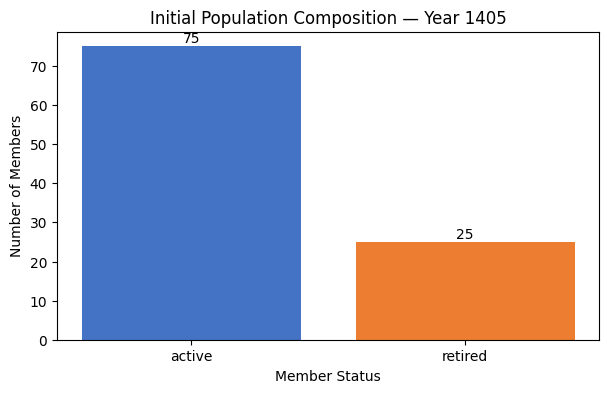

In [19]:
status_counts = people["status"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(
    status_counts.index,
    status_counts.values,
    color=["#4472C4", "#ED7D31"]
)

plt.title("Initial Population Composition — Year 1405")
plt.xlabel("Member Status")
plt.ylabel("Number of Members")

for i, value in enumerate(status_counts.values):
    plt.text(i, value + 1, str(value), ha="center")

plt.show()

# مرحله بیستم : نمودار توزیع سنی اعضا

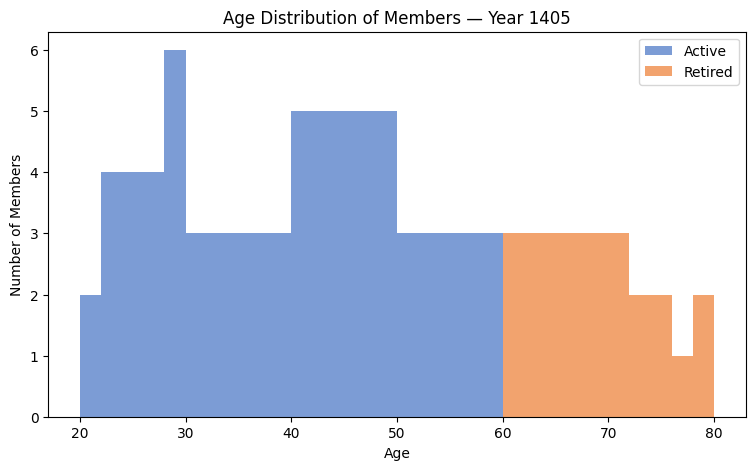

In [20]:
plt.figure(figsize=(9, 5))

plt.hist(
    active["age_1405"],
    bins=range(
        int(people["age_1405"].min()),
        int(people["age_1405"].max()) + 2,
        2
    ),
    alpha=0.7,
    label="Active",
    color="#4472C4"
)

plt.hist(
    retired["age_1405"],
    bins=range(
        int(people["age_1405"].min()),
        int(people["age_1405"].max()) + 2,
        2
    ),
    alpha=0.7,
    label="Retired",
    color="#ED7D31"
)

plt.title("Age Distribution of Members — Year 1405")
plt.xlabel("Age")
plt.ylabel("Number of Members")
plt.legend()

plt.show()

# مرحله بیست و یکم : گزارش نهایی کنترل‌های مرحله اول

In [21]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Required columns in Assumptions",
        "Required columns in Life_table",
        "Required columns in People",
        "Valid member status values",
        "Valid sex values",
        "Active service consistency",
        "Retired service consistency",
        "Annual pension formula consistency",
        "Monthly pension consistency"
    ],
    "Result": [
        "Pass" if expected_assumptions_cols.issubset(assumptions.columns) else "Fail",
        "Pass" if expected_life_table_cols.issubset(life_table.columns) else "Fail",
        "Pass" if expected_people_cols.issubset(people.columns) else "Fail",
        "Pass" if invalid_status_count == 0 else "Fail",
        "Pass" if invalid_sex_count == 0 else "Fail",
        "Pass" if (~active["service_check"]).sum() == 0 else "Fail",
        "Pass" if (~retired["service_check"]).sum() == 0 else "Fail",
        "Pass" if np.isclose(max_pension_error, 0) else "Fail",
        "Pass" if np.isclose(max_monthly_pension_error, 0) else "Fail"
    ]
})

display(validation_summary)

if (validation_summary["Result"] == "Pass").all():
    print("SUCCESS — Phase 1 data preparation and validation is complete.")
    print("The project is ready for the 10-year PAYG-DB projection phase.")
else:
    print("ATTENTION — Please resolve failed validation checks before projection.")

,Validation Check,Result
0,Required columns in Assumptions,Pass
1,Required columns in Life_table,Pass
2,Required columns in People,Pass
3,Valid member status values,Pass
4,Valid sex values,Pass
5,Active service consistency,Pass
6,Retired service consistency,Pass
7,Annual pension formula consistency,Pass
8,Monthly pension consistency,Pass


SUCCESS — Phase 1 data preparation and validation is complete.
The project is ready for the 10-year PAYG-DB projection phase.


# فاز دوم

### پیش‌بینی ۱۰ساله جمعیت (۱۴۰۵ - ۱۴۱۴)
در این بخش، جمعیت صندوق بازنشستگی را بر اساس احتمال بقای استخراج‌شده از جدول عمر ایران سال‌به‌سال منتقل می‌کنیم. 
شاغلانی که به سن ۶۰ سال می‌رسند بازنشسته شده و برای حفظ پایداری طرح، اعضای جدید به صندوق وارد می‌شوند

### مبانی اکچوئری پیشبینی جمعیت

در یک طرح بازنشستگی **PAYG-DB**، پیش‌بینی جمعیت پایه و اساس کل محاسبات مالی است. ما برای انتقال جمعیت از سال $t$ به سال $t+1$ از ابزارهای زیر استفاده می‌کنیم:

#### ۱. احتمال بقا ($p_x$):
احتمال اینکه فردی در سن $x$ تا سن $x+1$ زنده بماند. این اطلاعات مستقیماً از شیت `Life_table` (جدول عمر ایران) استخراج می‌شود:

$$p_x = 1 - q_x$$

که در آن $q_x$ احتمال مرگ در سن $x$ است.

#### ۲. قانون انتقال وضعیت (State Transition):
* **شاغلان (Active):** اگر فرد شاغل سن $x$ زنده بماند ($p_x$)، در سال بعد سن او $x+1$ و سابقه‌اش $s+1$ می‌شود.
* **بازنشستگان (Retired):** اگر فرد بازنشسته سن $x$ زنده بماند ($p_x$)، در سال بعد سن او $x+1$ می‌شود.
* **شرط بازنشستگی:** در این مدل، سن بازنشستگی هدف **۶۰ سال** فرض شده است. اعضای شاغلی که در انتهای سال به سن ۶۰ سالگی می‌رسند، در سال بعد به وضعیت بازنشسته منتقل می‌شوند.

#### ۳. ورودی‌های جدید (New Entrants):
در طرح‌های PAYG برای حفظ تعادل پویای سیستم، ورود اعضای جدید حیاتی است. در این فاز، برای جبران خروجی‌ها (ناشی از فوت یا بازنشستگی) و حفظ پویایی صندوق، فرض می‌کنیم تعداد ثابتی عضو جدید جوان (مثلاً بر اساس نرخ رشد جمعیت یا جایگزینی خروجی‌ها) وارد سیستم می‌شوند. طبق استاندارد، فرض ورود عضو جدید برای حفظ حجم کل جمعیت فعال در سطح ۷۵ نفر (یا نرخ رشد سالانه ۲٪) اعمال می‌شود. در این کد، ما سیاست ثابت نگه داشتن جمعیت شاغل در سطح ۷۵ نفر را پیاده‌سازی می‌کنیم تا اثرات ساختاری انتقال‌ها شفاف‌تر دیده شود (ورودی‌های جدید در سنین ۲۲ تا ۲۵ سال وارد می‌شوند).


# مرحله بیست و دوم : آماده‌سازی نگاشت جدول عمر

In [22]:
# ایجاد یک دیکشنری برای دسترسی سریع به احتمال بقا (px) بر اساس سن
# اگر سن خارج از جدول عمر باشد، احتمال بقا صفر فرض می‌شود.
px_dict = life_table.set_index("age")["px"].to_dict()


def get_survival_probability(age):
    """
    برگرداندن احتمال بقا برای سن مشخص.
    اگر سن در جدول نبود، احتمال بقا 0 فرض می‌شود.
    """
    return px_dict.get(int(age), 0.0)


print(f"Sample survival probability check:")
print(f"Age 25: {get_survival_probability(25):.6f}")
print(f"Age 59: {get_survival_probability(59):.6f}")
print(f"Age 80: {get_survival_probability(80):.6f}")


Sample survival probability check:
Age 25: 0.998818
Age 59: 0.991089
Age 80: 0.928510


# مرحله بیست و سوم : تعریف مکانیزم شبیه‌سازی یک‌ساله

In [23]:
def project_one_year(df_people, current_year, target_active_size=75):
    """
    شبیه‌سازی انتقال جمعیت برای یک سال تحصیلی/مالی:
    1. اعمال احتمال مرگ و میر بر روی تمامی اعضا
    2. افزایش سن برای زنده‌ماندگان
    3. افزایش سابقه برای شاغلان
    4. تغییر وضعیت شاغلانی که به سن بازنشستگی (60 سال) رسیده‌اند
    5. تزریق اعضای جدید (New Entrants) جهت حفظ تعادل جمعیتی شاغلان
    """
    next_population = []
    new_entrant_counter = 0

    # بررسی تک‌تک اعضای فعلی
    for _, person in df_people.iterrows():
        age = person[f"age_{current_year}"]
        px = get_survival_probability(age)

        # شبیه‌سازی بقا (قطعی بر اساس احتمال بقا در مقیاس جمعیت)
        # در محاسبات کلان اکچوئری، از ارزش چشمداشتی تعداد زنده‌ماندگان استفاده می‌شود (Deterministic Approach)
        survives = np.random.rand() < px

        if survives:
            new_person = person.copy()
            # افزایش سن
            new_person[f"age_{current_year + 1}"] = age + 1

            if person["status"] == "active":
                # افزایش سابقه کار شاغلان
                new_person[f"service_years_{current_year + 1}"] = (
                    person[f"service_years_{current_year}"] + 1
                )
                new_person[f"salary_{current_year + 1}"] = person[
                    f"salary_{current_year}"
                ]  # پایه حقوق بدون تغییر فعلی

                # بررسی شرط بازنشستگی (سن >= 60)
                if new_person[f"age_{current_year + 1}"] >= 60:
                    new_person["status"] = "retired"
                    # تعیین مبنای محاسبه مستمری (آخرین حقوق شاغلی)
                    new_person["benefit_salary_basis"] = person[
                        f"salary_{current_year}"
                    ]
                    # محاسبه مستمری بر اساس فرمول DB
                    # 2% * سابقه * حقوق مبنا
                    service = new_person[f"service_years_{current_year + 1}"]
                    ann_pension = 0.02 * service * person[f"salary_{current_year}"]
                    new_person[f"annual_pension_{current_year + 1}"] = (
                        ann_pension
                    )
                    new_person[f"monthly_pension_{current_year + 1}"] = (
                        ann_pension / 12
                    )
                else:
                    # همچنان شاغل باقی می‌ماند
                    new_person[f"annual_pension_{current_year + 1}"] = 0.0
                    new_person[f"monthly_pension_{current_year + 1}"] = 0.0
            else:
                # بازنشستگانی که زنده مانده‌اند سنشان زیاد می‌شود و مستمری قبل را می‌گیرند
                new_person[f"annual_pension_{current_year + 1}"] = person[
                    f"annual_pension_{current_year}"
                ]
                new_person[f"monthly_pension_{current_year + 1}"] = person[
                    f"monthly_pension_{current_year}"
                ]

            next_population.append(new_person)

    # شمارش شاغلان باقی‌مانده
    temp_df = pd.DataFrame(next_population)
    current_active_count = (
        (temp_df["status"] == "active").sum() if len(temp_df) > 0 else 0
    )

    # تزریق ورودی‌های جدید برای رساندن تعداد شاغلان به سقف هدف (target_active_size)
    needed_new_entrants = max(0, target_active_size - current_active_count)

    # فرض می‌کنیم مشخصات سیستماتیک ورودی‌های جدید بر اساس توزیع جوان جامعه است
    # سن ورود: 22 سال، سابقه: 0، حقوق پایه: میانگین حقوق ورودی‌ها (مثلا 20 میلیون تومان در سال یا مطابق میانگین اولیه)
    mean_start_salary = df_people.loc[
        df_people["status"] == "active", f"salary_{current_year}"
    ].mean()

    for i in range(needed_new_entrants):
        new_entrant_counter += 1
        new_id = f"NEW_{current_year+1}_{new_entrant_counter}"

        new_member = {
            "person_id": new_id,
            "status": "active",
            "sex": "M" if i % 2 == 0 else "F",  # ترکیب جنسی متوازن
            f"age_{current_year + 1}": 22,  # سن ورود جوان
            "entry_age": 22,
            f"service_years_{current_year + 1}": 0,
            f"salary_{current_year + 1}": mean_start_salary,
            "benefit_salary_basis": 0.0,
            f"annual_pension_{current_year + 1}": 0.0,
            f"monthly_pension_{current_year + 1}": 0.0,
        }
        next_population.append(pd.Series(new_member))

    return pd.DataFrame(next_population)

# مرحله بیست و چهارم : اجرای شبیه‌سازی زنجیره‌ای برای دوره ۱۰ساله

In [24]:
# تعیین سال مبدا و کپی ساختار اولیه
projection_data = {}
current_df = people.copy()

# قرار دادن سال مبدا در دیکشنری داده‌ها
start_year = 1405
projection_data[start_year] = current_df

# حلقه شبیه‌سازی سال‌به‌سال
for year in range(start_year, start_year + 10):
    print(f"Simulating year {year} -> {year+1}...")
    next_df = project_one_year(current_df, year, target_active_size=75)

    # ستون‌های سال جدید را به دیتافریم جدید منتقل می‌کنیم تا در دور بعدی استفاده شود
    # برای هماهنگی نام ستون‌ها در طول شبیه‌سازی
    next_df["age_temp"] = next_df[f"age_{year+1}"]
    next_df["service_temp"] = next_df.get(
        f"service_years_{year+1}", next_df.get("service_years_1405")
    )
    next_df["salary_temp"] = next_df.get(
        f"salary_{year+1}", next_df.get("salary_1405")
    )
    next_df["ann_pension_temp"] = next_df[f"annual_pension_{year+1}"]
    next_df["mon_pension_temp"] = next_df[f"monthly_pension_{year+1}"]

    # تخصیص نام ستون‌ها برای گام بعدی
    next_df[f"age_{year+1}"] = next_df["age_temp"]
    next_df[f"service_years_{year+1}"] = next_df["service_temp"]
    next_df[f"salary_{year+1}"] = next_df["salary_temp"]
    next_df[f"annual_pension_{year+1}"] = next_df["ann_pension_temp"]
    next_df[f"monthly_pension_{year+1}"] = next_df["mon_pension_temp"]

    # پاک‌سازی ستون‌های موقت
    next_df = next_df.drop(
        columns=[
            "age_temp",
            "service_temp",
            "salary_temp",
            "ann_pension_temp",
            "mon_pension_temp",
        ]
    )

    projection_data[year + 1] = next_df
    current_df = next_df

print("\n10-Year simulation completed successfully!")


Simulating year 1405 -> 1406...
Simulating year 1406 -> 1407...
Simulating year 1407 -> 1408...
Simulating year 1408 -> 1409...
Simulating year 1409 -> 1410...
Simulating year 1410 -> 1411...
Simulating year 1411 -> 1412...
Simulating year 1412 -> 1413...
Simulating year 1413 -> 1414...
Simulating year 1414 -> 1415...

10-Year simulation completed successfully!


# مرحله بیست و پنجم : استخراج نتایج آماری سالانه جمعیت

In [25]:
years = list(range(1405, 1416))
summary_records = []

for year in years:
    df_yr = projection_data[year]
    act_cnt = (df_yr["status"] == "active").sum()
    ret_cnt = (df_yr["status"] == "retired").sum()
    tot_cnt = len(df_yr)

    # میانگین سن‌ها
    avg_age_act = df_yr.loc[df_yr["status"] == "active", f"age_{year}"].mean()
    avg_age_ret = df_yr.loc[df_yr["status"] == "retired", f"age_{year}"].mean()

    summary_records.append(
        {
            "Year": year,
            "Active Members": act_cnt,
            "Retired Members": ret_cnt,
            "Total Population": tot_cnt,
            "Dependency Ratio": ret_cnt / act_cnt if act_cnt > 0 else 0,
            "Avg Active Age": avg_age_act,
            "Avg Retired Age": avg_age_ret,
        }
    )

df_pop_projection = pd.DataFrame(summary_records)
display(df_pop_projection)


,Year,Active Members,Retired Members,Total Population,Dependency Ratio,Avg Active Age,Avg Retired Age
0,1405,75,25,100,0.33,39.36,68.16
1,1406,75,27,102,0.36,39.35,68.48
2,1407,75,27,102,0.36,39.84,69.15
3,1408,75,27,102,0.36,40.33,69.67
4,1409,75,27,102,0.36,40.32,69.56
5,1410,75,25,100,0.33,40.81,69.40
6,1411,75,27,102,0.36,40.80,69.63
7,1412,75,27,102,0.36,41.29,69.85
8,1413,75,28,103,0.37,41.28,69.89
9,1414,75,28,103,0.37,41.77,70.57


# مرحله بیست و ششم : رسم نمودار روند تغییرات جمعیت

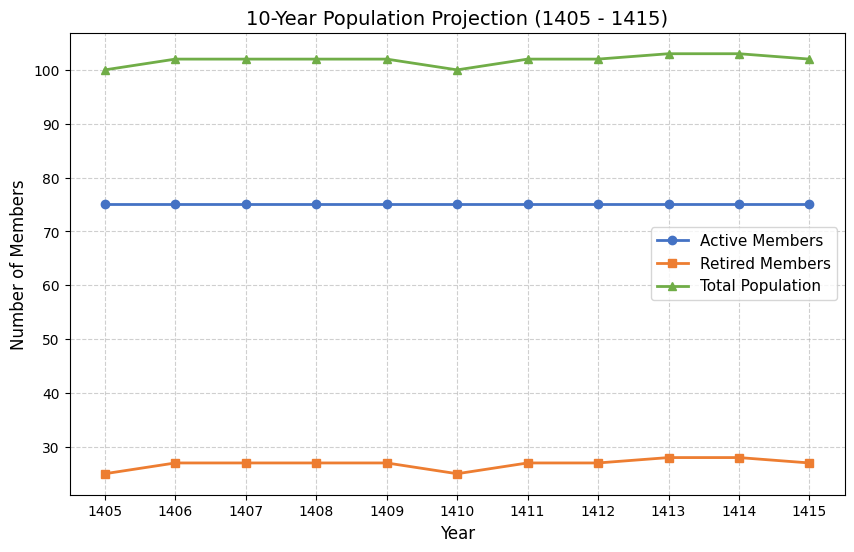

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_pop_projection["Year"],
    df_pop_projection["Active Members"],
    marker="o",
    label="Active Members",
    color="#4472C4",
    linewidth=2,
)
plt.plot(
    df_pop_projection["Year"],
    df_pop_projection["Retired Members"],
    marker="s",
    label="Retired Members",
    color="#ED7D31",
    linewidth=2,
)
plt.plot(
    df_pop_projection["Year"],
    df_pop_projection["Total Population"],
    marker="^",
    label="Total Population",
    color="#70AD47",
    linewidth=2,
)

plt.title("10-Year Population Projection (1405 - 1415)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Members", fontsize=12)
plt.xticks(df_pop_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.show()


# مرحله بیست و هفتم : رسم تغییرات نسبت وابستگی

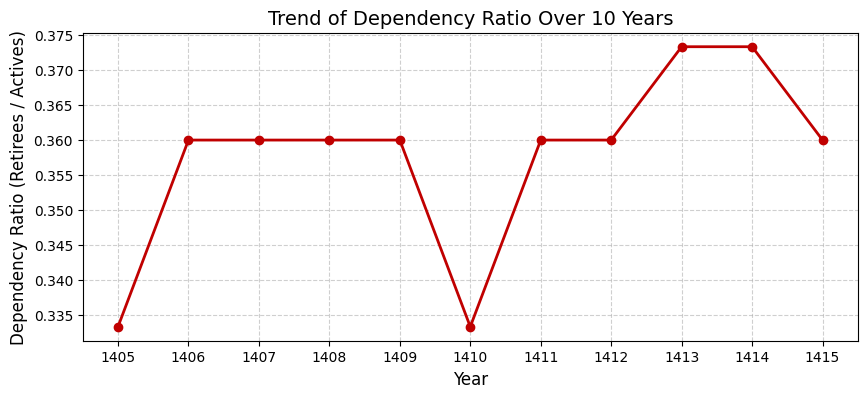

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(
    df_pop_projection["Year"],
    df_pop_projection["Dependency Ratio"],
    marker="o",
    color="#C00000",
    linewidth=2,
)
plt.title("Trend of Dependency Ratio Over 10 Years", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Dependency Ratio (Retirees / Actives)", fontsize=12)
plt.xticks(df_pop_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# فاز سوم
### محاسبات مالی و پیش‌بینی جریان وجوه نقد طرح PAYG-DB
در این بخش، بر اساس جمعیت پیش‌بینی‌شده در فاز قبل، جریان‌های درآمدی حق‌بیمه (با نرخ مصوب ۲۲.۵٪) و هزینه‌های پرداخت مستمری را محاسبه می‌کنیم. 
سپس کسری/مازاد سالانه و نرخ مشارکت تعادلی (BCR) را برای هر سال استخراج می‌نماییم

###  تعادل اکچوئری و جریانات مالی در طرح‌های توازن مستمر (Pay-As-You-Go)

در طرح‌های توازن مستمر (PAYG)، فرمول تعادل اکچوئری در سال $t$ به این صورت تعریف می‌شود:

#### ۱. درآمد حق‌بیمه ($C_t$ - Contribution Income):
حجم کل حق‌بیمه دریافتی از اعضای شاغل در سال $t$:

$$C_t = c \times \sum_{i \in \text{Active}} \text{Salary}_{i,t}$$

که در آن $c$ نرخ حق‌بیمه (Contribution Rate) است. بر اساس مفروضات اولیه صندوق، نرخ مشارکت مصوب طرح برابر **۲۲.۵٪** (شامل سهم کارفرما و کارمند) فرض می‌شود.

#### ۲. مخارج مزایا ($B_t$ - Benefit Expenditure):
کل تعهدات پرداخت مستمری به بازنشستگان در سال $t$:

$$B_t = \sum_{j \in \text{Retired}} \text{Annual Pension}_{j,t}$$

#### ۳. کسری یا مازاد سالانه ($S_t$ - Annual Cash Flow / Surplus / Deficit):
تفاضل منابع و مصارف سالانه:

$$S_t = C_t - B_t$$

#### ۴. نرخ مشارکت تعادلی ($BCR_t$ - Balanced Contribution Rate):
نرخ مشارکت تئوریکی که در آن جریان ورودی دقیقاً با جریان خروجی برابر شود ($C_t = B_t$) و به آن **نرخ تعادل PAYG** نیز می‌گویند:

$$BCR_t = \frac{B_t}{\sum_{i \in \text{Active}} \text{Salary}_{i,t}} = \text{Dependency Ratio}_t \times \frac{\text{Average Pension}_t}{\text{Average Salary}_t}$$


# مرحله بیست و هشتم : اعمال رشد دستمزد و محاسبات مالی سالانه

In [28]:
# اعمال رشد دستمزد و مستمری و محاسبه جریان مالی PAYG-DB

# مفروضات نهایی طرح PAYG-DB
contribution_rate_approved = 0.20   # نرخ کل حق بيمه: 20%
salary_growth_rate = 0.344          # رشد اسمی حقوق: 34.4%
pension_indexation_rate = 0.20      # شاخص‌بندی سالانه مستمری: 20%

financial_records = []

for year in range(1405, 1416):
    df_yr = projection_data[year].copy().reset_index(drop=True)

    # سال‌های بعد از سال مبنا: به‌روزرسانی حقوق و مستمری
    if year > 1405:
        prev_df = projection_data[year - 1].copy().reset_index(drop=True)

        # فقط اطلاعات لازم از سال قبل را با person_id نگاشت می‌کنیم
        previous_values = prev_df[
            [
                "person_id",
                "status",
                f"salary_{year - 1}",
                f"annual_pension_{year - 1}",
            ]
        ].drop_duplicates(subset="person_id", keep="last")

        previous_values = previous_values.rename(
            columns={
                "status": "previous_status",
                f"salary_{year - 1}": "previous_salary",
                f"annual_pension_{year - 1}": "previous_annual_pension",
            }
        )

        # الحاق بر اساس شناسه فرد، نه index
        df_yr = df_yr.merge(
            previous_values,
            on="person_id",
            how="left",
            validate="many_to_one",
        )

        # 1) رشد حقوق شاغلان موجود در سال قبل
        # ورودی‌های جدید در سال جاری previous_salary ندارند؛
        # حقوق اولیه آن‌ها توسط تابع project_one_year تعیین شده است.
        existing_active = (
            (df_yr["status"] == "active")
            & (df_yr["previous_status"] == "active")
            & (df_yr["previous_salary"].notna())
        )

        df_yr.loc[existing_active, f"salary_{year}"] = (
            df_yr.loc[existing_active, "previous_salary"]
            * (1 + salary_growth_rate)
        )

        # 2) شاخص‌بندی مستمری بازنشستگانی که از سال قبل بازنشسته بوده‌اند
        existing_retiree = (
            (df_yr["status"] == "retired")
            & (df_yr["previous_status"] == "retired")
            & (df_yr["previous_annual_pension"].notna())
        )

        df_yr.loc[existing_retiree, f"annual_pension_{year}"] = (
            df_yr.loc[existing_retiree, "previous_annual_pension"]
            * (1 + pension_indexation_rate)
        )

        # مستمری بازنشستگان جدید دست‌نخورده می‌ماند، زیرا در project_one_year محاسبه شده است.
        df_yr[f"monthly_pension_{year}"] = (
            df_yr[f"annual_pension_{year}"] / 12
        )

        # حذف ستون‌های کمکی
        df_yr = df_yr.drop(
            columns=[
                "previous_status",
                "previous_salary",
                "previous_annual_pension",
            ]
        )

        # ذخیره نسخه اصلاح‌شده در خروجی شبیه‌سازی
        projection_data[year] = df_yr.copy()

    # 3) محاسبه درآمد حق‌بیمه و هزینه مزایا
    total_payroll = df_yr.loc[
        df_yr["status"] == "active",
        f"salary_{year}",
    ].sum()

    total_benefits = df_yr.loc[
        df_yr["status"] == "retired",
        f"annual_pension_{year}",
    ].sum()

    contributions = contribution_rate_approved * total_payroll
    net_cash_flow = contributions - total_benefits

    # نرخ حق‌بیمه لازم برای برقرار شدن تعادل سالانه PAYG
    bcr = total_benefits / total_payroll if total_payroll > 0 else 0.0

    financial_records.append(
        {
            "Year": year,
            "Total Payroll": total_payroll,
            "Approved Contributions (20%)": contributions,
            "Total Benefit Payments": total_benefits,
            "Net Cash Flow (Surplus/Deficit)": net_cash_flow,
            "Balanced Contribution Rate (BCR)": bcr,
        }
    )

df_financial_projection = pd.DataFrame(financial_records)

display(
    df_financial_projection.style.format(
        {
            "Total Payroll": "{:,.0f}",
            "Approved Contributions (20%)": "{:,.0f}",
            "Total Benefit Payments": "{:,.0f}",
            "Net Cash Flow (Surplus/Deficit)": "{:,.0f}",
            "Balanced Contribution Rate (BCR)": "{:.2%}",
        }
    )
)


,Year,Total Payroll,Approved Contributions (20%),Total Benefit Payments,Net Cash Flow (Surplus/Deficit),Balanced Contribution Rate (BCR)
0,1405,"33,700","6,740","11,228","-4,488",33.32%
1,1406,"44,310","8,862","14,132","-5,270",31.89%
2,1407,"58,731","11,746","16,739","-4,993",28.50%
3,1408,"77,674","15,535","19,759","-4,225",25.44%
4,1409,"100,697","20,139","22,858","-2,718",22.70%
5,1410,"132,696","26,539","24,860","1,679",18.73%
6,1411,"170,942","34,188","30,616","3,572",17.91%
7,1412,"224,619","44,924","35,504","9,420",15.81%
8,1413,"287,811","57,562","41,898","15,665",14.56%
9,1414,"377,209","75,442","48,211","27,231",12.78%


# مرحله بیست و نهم : محاسبه ذخیره تجمعی صندوق

In [29]:
# محاسبه ذخیره تجمعی صندوق (Cumulative Reserve)

investment_return_rate = 0.18  # نرخ بازده سالانه سرمایه‌گذاری: 18%
initial_reserve = 0.0          # دارایی اولیه صندوق در ابتدای سال 1405

cumulative_reserves = []
reserve = initial_reserve

for _, row in df_financial_projection.iterrows():
    # ابتدا ذخیره ابتدای سال بازده می‌گیرد، سپس جریان نقدی سال به آن افزوده می‌شود.
    reserve = (
        reserve * (1 + investment_return_rate)
        + row["Net Cash Flow (Surplus/Deficit)"]
    )
    cumulative_reserves.append(reserve)

df_financial_projection["Cumulative Reserve"] = cumulative_reserves

display(
    df_financial_projection[
        [
            "Year",
            "Net Cash Flow (Surplus/Deficit)",
            "Cumulative Reserve",
        ]
    ].style.format(
        {
            "Net Cash Flow (Surplus/Deficit)": "{:,.0f}",
            "Cumulative Reserve": "{:,.0f}",
        }
    )
)

,Year,Net Cash Flow (Surplus/Deficit),Cumulative Reserve
0,1405,"-4,488","-4,488"
1,1406,"-5,270","-10,565"
2,1407,"-4,993","-17,460"
3,1408,"-4,225","-24,827"
4,1409,"-2,718","-32,015"
5,1410,"1,679","-36,098"
6,1411,"3,572","-39,023"
7,1412,"9,420","-36,628"
8,1413,"15,665","-27,556"
9,1414,"27,231","-5,285"


# مرحله سی‌ام : نمودار درآمد حق‌بیمه و هزینه مزایا

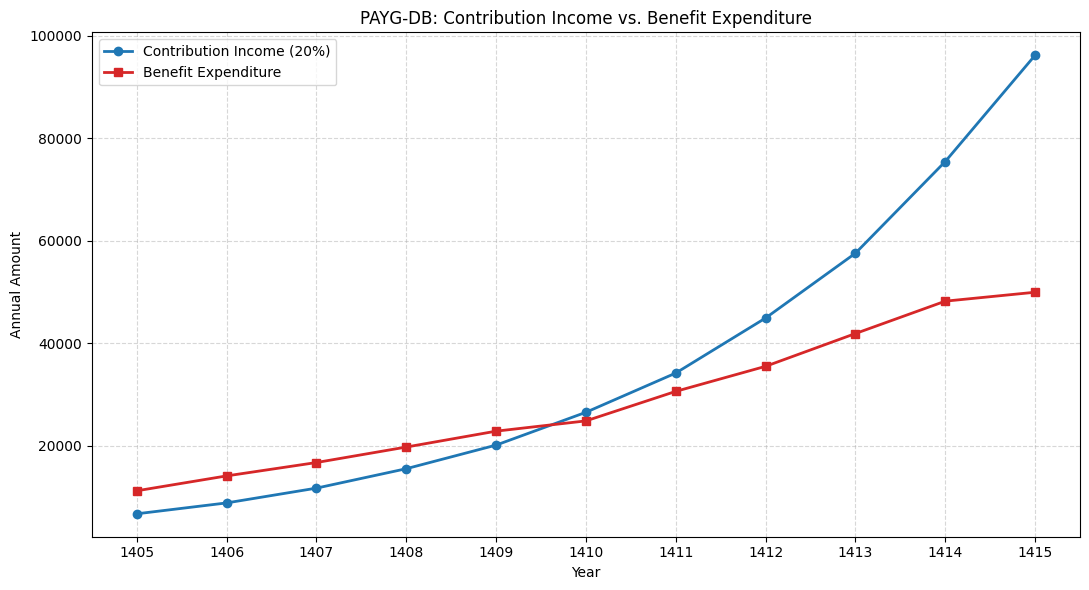

In [30]:
# مقایسه درآمد حق‌بیمه و هزینه پرداخت مستمری

plt.figure(figsize=(11, 6))

plt.plot(
    df_financial_projection["Year"],
    df_financial_projection["Approved Contributions (20%)"],
    marker="o",
    markersize=6,
    label="Contribution Income (20%)",
    color="#1F77B4",
    linewidth=2,
)

plt.plot(
    df_financial_projection["Year"],
    df_financial_projection["Total Benefit Payments"],
    marker="s",
    markersize=6,
    label="Benefit Expenditure",
    color="#D62728",
    linewidth=2,
)

plt.title("PAYG-DB: Contribution Income vs. Benefit Expenditure")
plt.xlabel("Year")
plt.ylabel("Annual Amount")
plt.xticks(df_financial_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# مرحله سی و یکم : نمودار نرخ حق‌بیمه تعادلی در مقایسه با نرخ مصوب

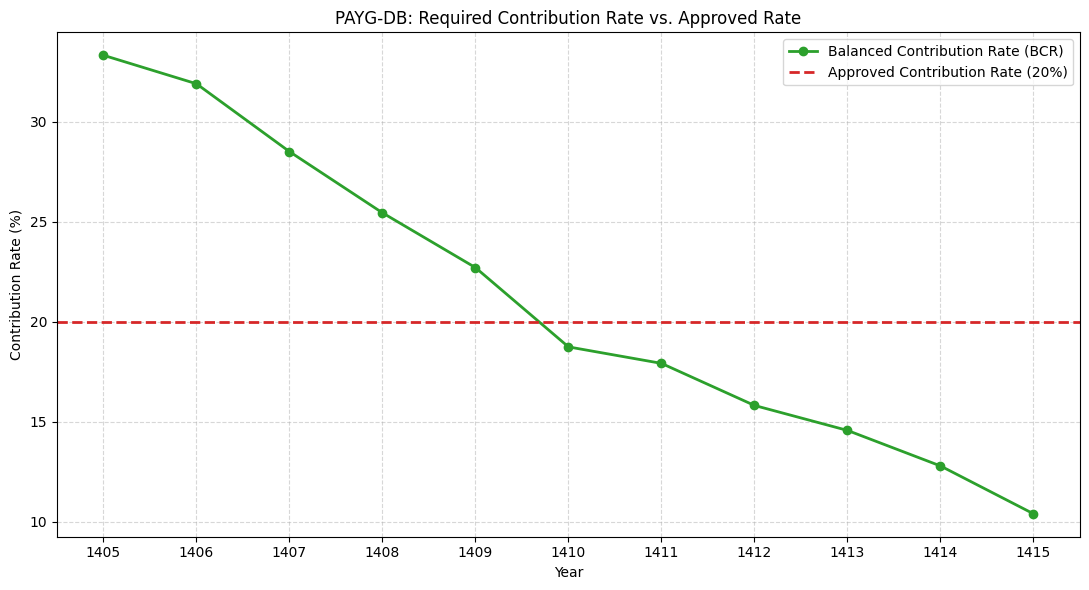

In [31]:
# مقایسه نرخ حق‌بیمه تعادلی (BCR) با نرخ حق‌بیمه مصوب

plt.figure(figsize=(11, 6))

plt.plot(
    df_financial_projection["Year"],
    df_financial_projection["Balanced Contribution Rate (BCR)"] * 100,
    marker="o",
    markersize=6,
    label="Balanced Contribution Rate (BCR)",
    color="#2CA02C",
    linewidth=2,
)

plt.axhline(
    y=contribution_rate_approved * 100,
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label="Approved Contribution Rate (20%)",
)

plt.title("PAYG-DB: Required Contribution Rate vs. Approved Rate")
plt.xlabel("Year")
plt.ylabel("Contribution Rate (%)")
plt.xticks(df_financial_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

###  قاعده تفسیر نمودار نرخ حق‌بیمه متوازن ($BCR$)

نرخ حق‌بیمه متوازن سالانه از رابطه زیر به دست می‌آید:

$$BCR_t = \frac{B_t}{\text{Payroll}_t}$$

برای ارزیابی وضعیت پایداری صندوق، نرخ $BCR_t$ با نرخ حق‌بیمه مصوب طرح (مثلاً $20\%$) مقایسه می‌شود:

* **اگر $BCR_t > 20\%$ باشد:**
  طرح در سال $t$ با نرخ مصوب ۲۰ درصد در تعادل نیست و دچار **کسری نقدینگی** است.

* **اگر $BCR_t < 20\%$ باشد:**
  نرخ مصوب برای تأمین هزینه مستمری‌های همان سال کافی بوده و طرح دارای **مازاد نقدی** است.


# مرحله سی و دوم : نمودار کسری/مازاد جریان نقدی سالانه

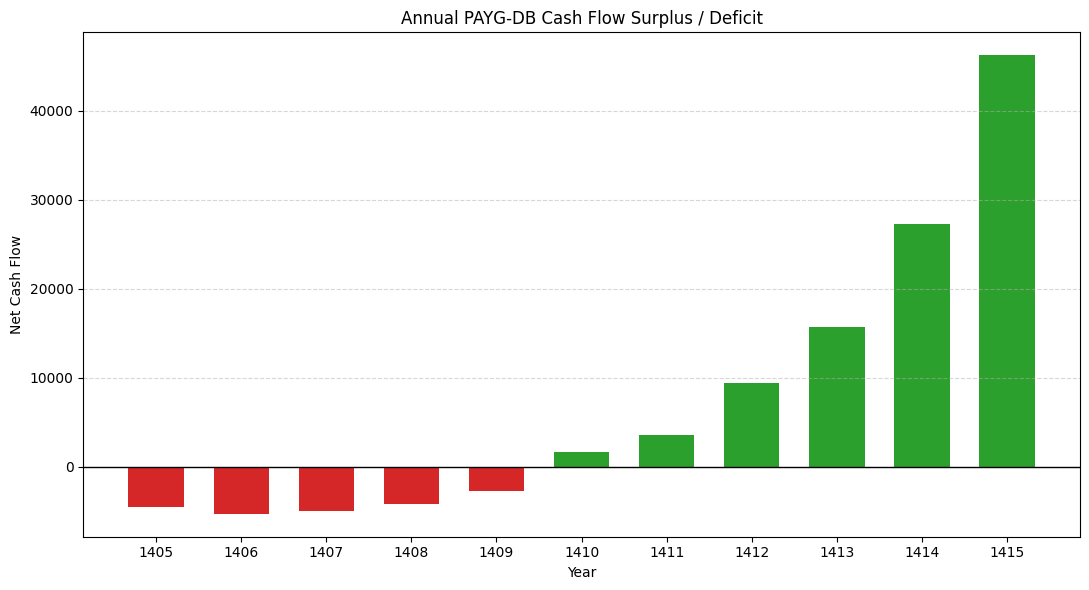

In [32]:
# نمودار کسری یا مازاد سالانه جریان نقدی

plt.figure(figsize=(11, 6))

bar_colors = [
    "#2CA02C" if value >= 0 else "#D62728"
    for value in df_financial_projection["Net Cash Flow (Surplus/Deficit)"]
]

plt.bar(
    df_financial_projection["Year"],
    df_financial_projection["Net Cash Flow (Surplus/Deficit)"],
    color=bar_colors,
    width=0.65,
)

plt.axhline(
    y=0,
    color="black",
    linewidth=1,
)

plt.title("Annual PAYG-DB Cash Flow Surplus / Deficit")
plt.xlabel("Year")
plt.ylabel("Net Cash Flow")
plt.xticks(df_financial_projection["Year"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# مرحله سی و سوم : نمودار روند ذخیره تجمعی صندوق

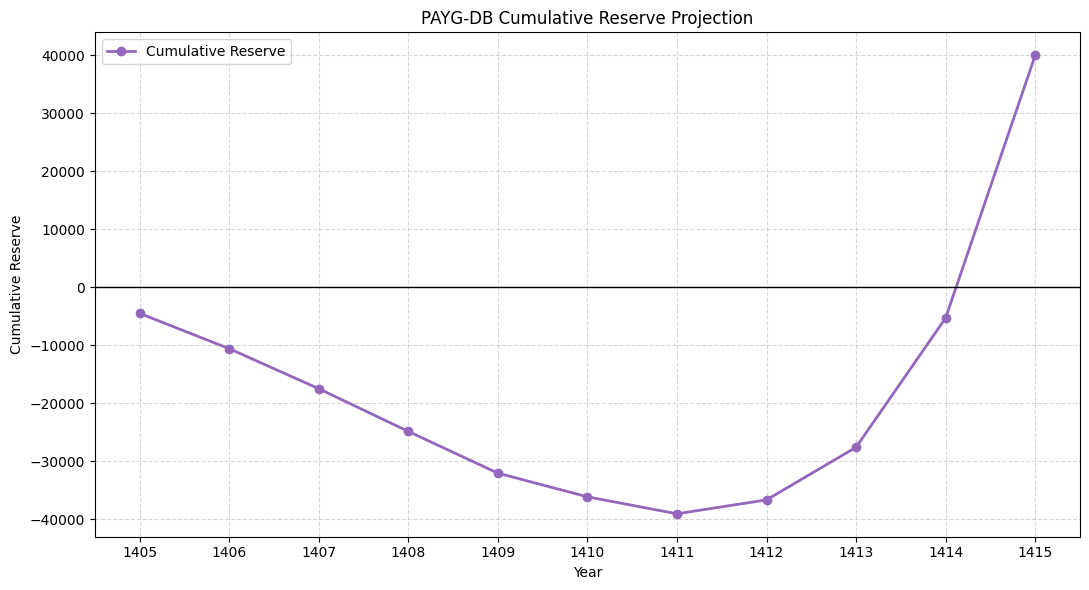

In [33]:
# نمودار روند ذخیره تجمعی صندوق

plt.figure(figsize=(11, 6))

plt.plot(
    df_financial_projection["Year"],
    df_financial_projection["Cumulative Reserve"],
    marker="o",
    markersize=6,
    color="#9467BD",
    linewidth=2,
    label="Cumulative Reserve",
)

plt.axhline(
    y=0,
    color="black",
    linewidth=1,
)

plt.title("PAYG-DB Cumulative Reserve Projection")
plt.xlabel("Year")
plt.ylabel("Cumulative Reserve")
plt.xticks(df_financial_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# مرحله سی و چهارم : جدول نهایی خلاصه برای گزارش

In [34]:
#  جدول خلاصه نهایی نتایج مالی PAYG-DB

final_financial_summary = df_financial_projection[
    [
        "Year",
        "Total Payroll",
        "Approved Contributions (20%)",
        "Total Benefit Payments",
        "Net Cash Flow (Surplus/Deficit)",
        "Balanced Contribution Rate (BCR)",
        "Cumulative Reserve",
    ]
].copy()

display(
    final_financial_summary.style.format(
        {
            "Total Payroll": "{:,.0f}",
            "Approved Contributions (20%)": "{:,.0f}",
            "Total Benefit Payments": "{:,.0f}",
            "Net Cash Flow (Surplus/Deficit)": "{:,.0f}",
            "Balanced Contribution Rate (BCR)": "{:.2%}",
            "Cumulative Reserve": "{:,.0f}",
        }
    )
)


,Year,Total Payroll,Approved Contributions (20%),Total Benefit Payments,Net Cash Flow (Surplus/Deficit),Balanced Contribution Rate (BCR),Cumulative Reserve
0,1405,"33,700","6,740","11,228","-4,488",33.32%,"-4,488"
1,1406,"44,310","8,862","14,132","-5,270",31.89%,"-10,565"
2,1407,"58,731","11,746","16,739","-4,993",28.50%,"-17,460"
3,1408,"77,674","15,535","19,759","-4,225",25.44%,"-24,827"
4,1409,"100,697","20,139","22,858","-2,718",22.70%,"-32,015"
5,1410,"132,696","26,539","24,860","1,679",18.73%,"-36,098"
6,1411,"170,942","34,188","30,616","3,572",17.91%,"-39,023"
7,1412,"224,619","44,924","35,504","9,420",15.81%,"-36,628"
8,1413,"287,811","57,562","41,898","15,665",14.56%,"-27,556"
9,1414,"377,209","75,442","48,211","27,231",12.78%,"-5,285"


# فاز چهارم

### شاخص‌های کلیدی PAYG-DB

# مرحله سی و پنجم : استخراج نقاط بحرانی و شاخص‌های مالی

In [35]:
#  استخراج شاخص‌های کلیدی پایداری مالی طرح PAYG-DB

financial_df = df_financial_projection.copy()

net_cash_flow_col = "Net Cash Flow (Surplus/Deficit)"
reserve_col = "Cumulative Reserve"
bcr_col = "Balanced Contribution Rate (BCR)"

# سال شروع مازاد جریان نقدی
positive_cash_flow_years = financial_df.loc[
    financial_df[net_cash_flow_col] >= 0,
    "Year",
]

first_surplus_year = (
    int(positive_cash_flow_years.iloc[0])
    if not positive_cash_flow_years.empty
    else None
)

# سال بازیابی ذخیره تجمعی
positive_reserve_years = financial_df.loc[
    financial_df[reserve_col] >= 0,
    "Year",
]

first_positive_reserve_year = (
    int(positive_reserve_years.iloc[0])
    if not positive_reserve_years.empty
    else None
)

# شدیدترین کسری سالانه
worst_cash_flow_index = financial_df[net_cash_flow_col].idxmin()
worst_cash_flow_year = int(
    financial_df.loc[worst_cash_flow_index, "Year"]
)
worst_cash_flow_value = financial_df.loc[
    worst_cash_flow_index,
    net_cash_flow_col,
]

# کمترین سطح ذخیره تجمعی
minimum_reserve_index = financial_df[reserve_col].idxmin()
minimum_reserve_year = int(
    financial_df.loc[minimum_reserve_index, "Year"]
)
minimum_reserve_value = financial_df.loc[
    minimum_reserve_index,
    reserve_col,
]

# بیشترین و کمترین نرخ حق‌بیمه تعادلی
maximum_bcr = financial_df[bcr_col].max()
maximum_bcr_year = int(
    financial_df.loc[financial_df[bcr_col].idxmax(), "Year"]
)

minimum_bcr = financial_df[bcr_col].min()
minimum_bcr_year = int(
    financial_df.loc[financial_df[bcr_col].idxmin(), "Year"]
)

# مجموع درآمدها، هزینه‌ها و جریان نقدی بدون انباشت بازده سرمایه‌گذاری
total_contributions = financial_df[
    "Approved Contributions (20%)"
].sum()

total_benefits = financial_df[
    "Total Benefit Payments"
].sum()

total_net_cash_flow = financial_df[
    net_cash_flow_col
].sum()

# ذخیره پایان افق پیش‌بینی
ending_reserve = financial_df.iloc[-1][reserve_col]

key_indicators = pd.DataFrame(
    {
        "Indicator": [
            "First Annual Cash-Flow Surplus Year",
            "First Non-Negative Reserve Year",
            "Worst Annual Cash-Flow Year",
            "Worst Annual Cash Flow",
            "Minimum Reserve Year",
            "Minimum Cumulative Reserve",
            "Maximum Balanced Contribution Rate",
            "Maximum BCR Year",
            "Minimum Balanced Contribution Rate",
            "Minimum BCR Year",
            "Total Contributions",
            "Total Benefit Payments",
            "Total Net Cash Flow",
            "Ending Cumulative Reserve",
        ],
        "Value": [
            first_surplus_year,
            first_positive_reserve_year,
            worst_cash_flow_year,
            worst_cash_flow_value,
            minimum_reserve_year,
            minimum_reserve_value,
            maximum_bcr,
            maximum_bcr_year,
            minimum_bcr,
            minimum_bcr_year,
            total_contributions,
            total_benefits,
            total_net_cash_flow,
            ending_reserve,
        ],
    }
)

display(key_indicators)

,Indicator,Value
0,First Annual Cash-Flow Surplus Year,"1,410.00"
1,First Non-Negative Reserve Year,"1,415.00"
2,Worst Annual Cash-Flow Year,"1,406.00"
3,Worst Annual Cash Flow,"-5,269.63"
4,Minimum Reserve Year,"1,411.00"
5,Minimum Cumulative Reserve,"-39,023.36"
6,Maximum Balanced Contribution Rate,0.33
7,Maximum BCR Year,"1,405.00"
8,Minimum Balanced Contribution Rate,0.10
9,Minimum BCR Year,"1,415.00"


# مرحله سی و ششم : ساخت جدول سالانه وضعیت مالی

In [36]:
#  طبقه‌بندی وضعیت مالی سالانه طرح

financial_status = df_financial_projection[
    [
        "Year",
        "Approved Contributions (20%)",
        "Total Benefit Payments",
        "Net Cash Flow (Surplus/Deficit)",
        "Balanced Contribution Rate (BCR)",
        "Cumulative Reserve",
    ]
].copy()

financial_status["Annual Cash-Flow Status"] = np.where(
    financial_status["Net Cash Flow (Surplus/Deficit)"] >= 0,
    "Surplus",
    "Deficit",
)

financial_status["PAYG Balance Status"] = np.where(
    financial_status["Balanced Contribution Rate (BCR)"]
    <= contribution_rate_approved,
    "Financially Balanced",
    "Financially Unbalanced",
)

financial_status["Reserve Status"] = np.where(
    financial_status["Cumulative Reserve"] >= 0,
    "Non-Negative Reserve",
    "Negative Reserve",
)

display(
    financial_status.style.format(
        {
            "Approved Contributions (20%)": "{:,.0f}",
            "Total Benefit Payments": "{:,.0f}",
            "Net Cash Flow (Surplus/Deficit)": "{:,.0f}",
            "Balanced Contribution Rate (BCR)": "{:.2%}",
            "Cumulative Reserve": "{:,.0f}",
        }
    )
)


,Year,Approved Contributions (20%),Total Benefit Payments,Net Cash Flow (Surplus/Deficit),Balanced Contribution Rate (BCR),Cumulative Reserve,Annual Cash-Flow Status,PAYG Balance Status,Reserve Status
0,1405,"6,740","11,228","-4,488",33.32%,"-4,488",Deficit,Financially Unbalanced,Negative Reserve
1,1406,"8,862","14,132","-5,270",31.89%,"-10,565",Deficit,Financially Unbalanced,Negative Reserve
2,1407,"11,746","16,739","-4,993",28.50%,"-17,460",Deficit,Financially Unbalanced,Negative Reserve
3,1408,"15,535","19,759","-4,225",25.44%,"-24,827",Deficit,Financially Unbalanced,Negative Reserve
4,1409,"20,139","22,858","-2,718",22.70%,"-32,015",Deficit,Financially Unbalanced,Negative Reserve
5,1410,"26,539","24,860","1,679",18.73%,"-36,098",Surplus,Financially Balanced,Negative Reserve
6,1411,"34,188","30,616","3,572",17.91%,"-39,023",Surplus,Financially Balanced,Negative Reserve
7,1412,"44,924","35,504","9,420",15.81%,"-36,628",Surplus,Financially Balanced,Negative Reserve
8,1413,"57,562","41,898","15,665",14.56%,"-27,556",Surplus,Financially Balanced,Negative Reserve
9,1414,"75,442","48,211","27,231",12.78%,"-5,285",Surplus,Financially Balanced,Negative Reserve


# مرحله سی و هفتم : تحلیل حساسیت کوتاه

در این تحلیل، جمعیت و وضعیت اعضا ثابت نگه داشته می‌شود و فقط اثر تغییر مفروضات مالی بررسی می‌شود. همچنین اصلاح مفهومی مهم: افزایش شاخص‌بندی مستمری به ۳۰٪ برای صندوق یک سناریوی نامطلوب است، نه خوش‌بینانه

In [37]:
#  تحلیل حساسیت کوتاه مفروضات مالی PAYG-DB

base_salary_growth = 0.344
base_pension_index = 0.20
contribution_rate = 0.20

scenarios = {
    "Base": {
        "salary_growth": 0.344,
        "pension_index": 0.20,
        "investment_return": 0.18,
    },
    "Low Salary Growth": {
        "salary_growth": 0.25,
        "pension_index": 0.20,
        "investment_return": 0.18,
    },
    "Low Investment Return": {
        "salary_growth": 0.344,
        "pension_index": 0.20,
        "investment_return": 0.10,
    },
    "High Pension Indexation": {
        "salary_growth": 0.344,
        "pension_index": 0.30,
        "investment_return": 0.18,
    },
}

sensitivity_results = []
sensitivity_paths = []

base_year = int(df_financial_projection["Year"].min())

for scenario_name, assumptions in scenarios.items():
    reserve = 0.0
    first_surplus_year = None
    first_recovery_year = None

    for _, row in df_financial_projection.iterrows():
        year = int(row["Year"])
        elapsed_years = year - base_year

        # تعدیل درآمد حقوق با فرض رشد حقوق سناریو
        payroll = row["Total Payroll"] * (
            (1 + assumptions["salary_growth"])
            / (1 + base_salary_growth)
        ) ** elapsed_years

        # تعدیل هزینه مستمری با فرض شاخص‌بندی سناریو
        benefits = row["Total Benefit Payments"] * (
            (1 + assumptions["pension_index"])
            / (1 + base_pension_index)
        ) ** elapsed_years

        contributions = contribution_rate * payroll
        net_cash_flow = contributions - benefits

        reserve = (
            reserve * (1 + assumptions["investment_return"])
            + net_cash_flow
        )

        if net_cash_flow >= 0 and first_surplus_year is None:
            first_surplus_year = year

        if reserve >= 0 and first_recovery_year is None:
            first_recovery_year = year

        sensitivity_paths.append(
            {
                "Scenario": scenario_name,
                "Year": year,
                "Net Cash Flow": net_cash_flow,
                "Cumulative Reserve": reserve,
            }
        )

    sensitivity_results.append(
        {
            "Scenario": scenario_name,
            "Salary Growth": assumptions["salary_growth"],
            "Pension Indexation": assumptions["pension_index"],
            "Investment Return": assumptions["investment_return"],
            "First Surplus Year": (
                first_surplus_year
                if first_surplus_year is not None
                else "Not Reached"
            ),
            "First Recovery Year": (
                first_recovery_year
                if first_recovery_year is not None
                else "Not Reached"
            ),
            "Ending Reserve (1415)": reserve,
        }
    )

df_sensitivity = pd.DataFrame(sensitivity_results)
df_sensitivity_paths = pd.DataFrame(sensitivity_paths)

display(
    df_sensitivity.style.format(
        {
            "Salary Growth": "{:.1%}",
            "Pension Indexation": "{:.1%}",
            "Investment Return": "{:.1%}",
            "Ending Reserve (1415)": "{:,.0f}",
        }
    )
)

,Scenario,Salary Growth,Pension Indexation,Investment Return,First Surplus Year,First Recovery Year,Ending Reserve (1415)
0,Base,34.4%,20.0%,18.0%,1410,1415,"39,982"
1,Low Salary Growth,25.0%,20.0%,18.0%,Not Reached,Not Reached,"-190,852"
2,Low Investment Return,34.4%,20.0%,10.0%,1410,1414,"67,782"
3,High Pension Indexation,34.4%,30.0%,18.0%,Not Reached,Not Reached,"-298,570"


# مرحله سی و هشتم : نمودار مقایسه‌ای سناریوها

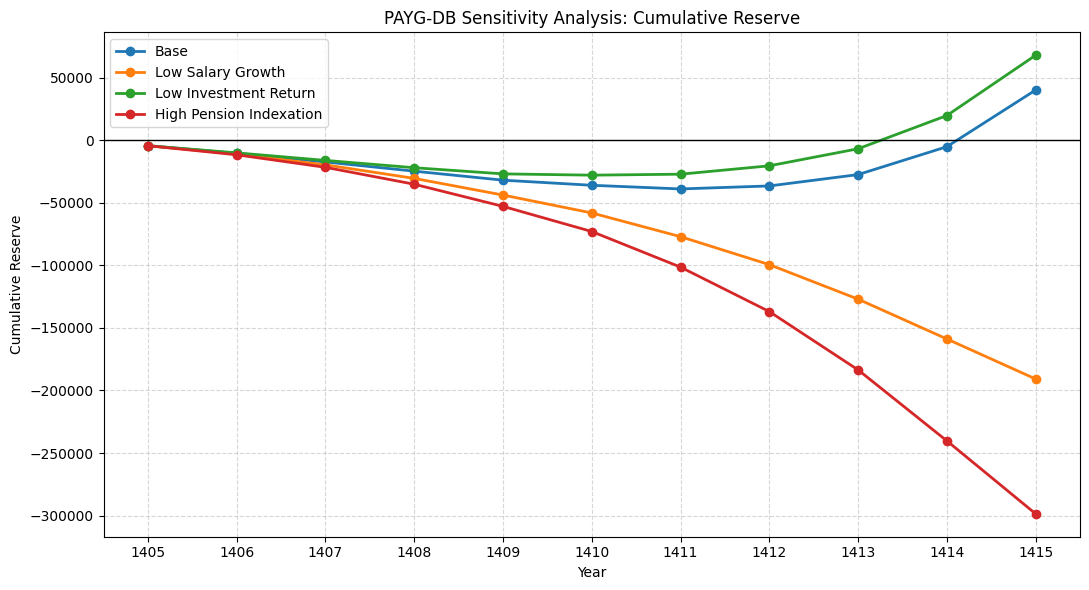

In [38]:
plt.figure(figsize=(11, 6))

for scenario_name in df_sensitivity_paths["Scenario"].unique():
    scenario_data = df_sensitivity_paths[
        df_sensitivity_paths["Scenario"] == scenario_name
    ]

    plt.plot(
        scenario_data["Year"],
        scenario_data["Cumulative Reserve"],
        marker="o",
        linewidth=2,
        label=scenario_name,
    )

plt.axhline(y=0, color="black", linewidth=1)
plt.title("PAYG-DB Sensitivity Analysis: Cumulative Reserve")
plt.xlabel("Year")
plt.ylabel("Cumulative Reserve")
plt.xticks(df_financial_projection["Year"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
